<a href="https://colab.research.google.com/github/OutisAyo/council-classifier-/blob/main/notebooks/01_data_exploration.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

 Machine Learning for Automated Classification and Prioritisation of Local Council Service Requests in the UK
Notebook 01 — Data Exploration

**Author:** Fashina Fuad Ayomide  
**MSc Data Science, University of South Wales**

This notebook loads the Swansea Council FOI dataset (2022-2024) and performs initial data exploration to understand its structure, distribution, and quality before modelling.

## Mounting Google Drive

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## Importing the libraries

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## Importing the dataset

In [ ]:
dataset = pd.read_csv('/content/drive/MyDrive/council-classifier/swansea_council_foi_data.csv')
dataset.head()

,source_year,category_code,complaint_type_code,assigned_department,target_date,date_received,date_closed
0,2022,Live Rat in House * Urgent*,Animal Warden - Out of Hours,Pollution Division,03/01/2022,01/01/2022,01/01/2022
1,2022,Recycling,Multiple Bag & Liner Request,Waste Management,10/01/2022,01/01/2022,05/06/2026
2,2022,Recycling,Multiple Bag & Liner Request,Waste Management,10/01/2022,01/01/2022,05/06/2026
3,2022,Domestic,Bulk Request,Waste Management,10/01/2022,01/01/2022,10/01/2022
4,2022,"General Rubbish/hous,building",NaN,Housing Division,10/01/2022,01/01/2022,06/01/2022


## Understanding the dataset structure

In [ ]:
print("Dataset shape:", dataset.shape)
print("\nColumn types:")
print(dataset.dtypes)
print("\nMissing values per column:")
print(dataset.isnull().sum())

Dataset shape: (260286, 7)

Column types:
source_year             int64
category_code          object
complaint_type_code    object
assigned_department    object
target_date            object
date_received          object
date_closed            object
dtype: object

Missing values per column:
source_year                0
category_code             32
complaint_type_code    16240
assigned_department        0
target_date                0
date_received              0
date_closed             5860
dtype: int64


## Analysing the target variable (assigned_department)

The department is what our classifier will predict, so understanding its distribution is critical.

In [ ]:
print("Records per department:")
print(dataset['assigned_department'].value_counts())
print("\nPercentage per department:")
print(dataset['assigned_department'].value_counts(normalize=True) * 100)

Records per department:
assigned_department
Waste Management              197555
Pollution Division             36262
Housing Division               10649
Licensing Division              8685
Food and Safety Division        6020
Trading Standards Division      1066
Administration                    37
Building Control                  12
Name: count, dtype: int64

Percentage per department:
assigned_department
Waste Management              75.899203
Pollution Division            13.931598
Housing Division               4.091269
Licensing Division             3.336714
Food and Safety Division       2.312840
Trading Standards Division     0.409549
Administration                 0.014215
Building Control               0.004610
Name: proportion, dtype: float64


## Visualising the department distribution

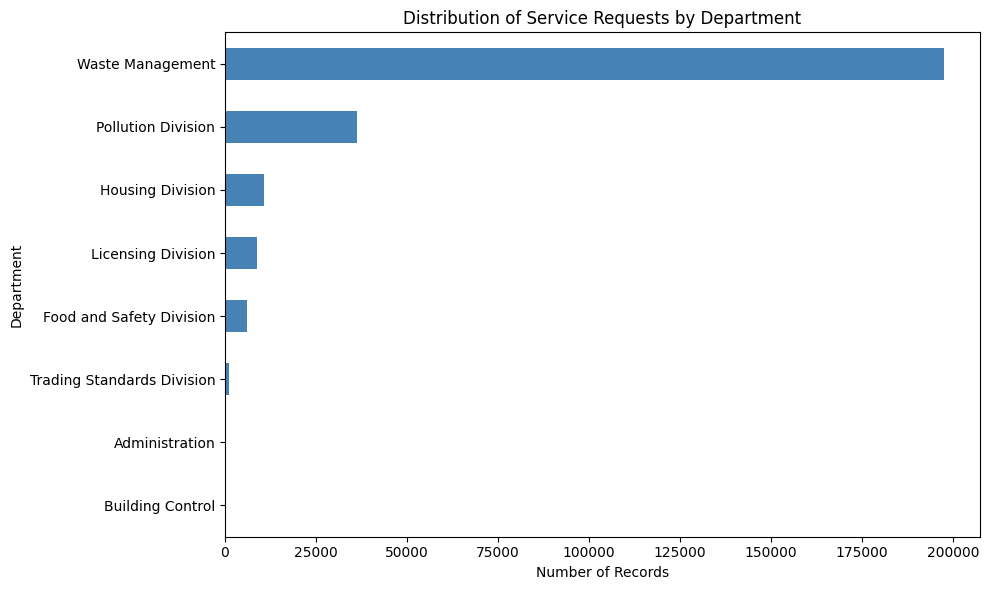

In [ ]:
plt.figure(figsize=(10, 6))
dataset['assigned_department'].value_counts().plot(kind='barh', color='steelblue')
plt.title('Distribution of Service Requests by Department')
plt.xlabel('Number of Records')
plt.ylabel('Department')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

## Analysing the category codes

The category_code will be one of the primary text features for classification.

In [ ]:
print("Number of unique category codes:", dataset['category_code'].nunique())
print("\nTop 15 most common categories:")
print(dataset['category_code'].value_counts().head(15))

Number of unique category codes: 276

Top 15 most common categories:
category_code
Recycling                        81780
Domestic                         73501
Street Scene                     28032
Rats                             14271
Trade                             5213
Enforcement                       4849
Unreported Flytipping             3942
Dual Badge Driver                 2833
Pest control general enquiry      2652
Barking Dog                       2595
Amplified Music                   2536
New Business Advice               2312
Temporary Event Notification      2192
General Rubbish/hous,building     1765
Private Hire Vehicle              1705
Name: count, dtype: int64


## Analysing the complaint types

In [ ]:
print("Number of unique complaint types:", dataset['complaint_type_code'].nunique())
print("Records with missing complaint_type:", dataset['complaint_type_code'].isnull().sum())
print("\nTop 15 most common complaint types:")
print(dataset['complaint_type_code'].value_counts().head(15))

Number of unique complaint types: 263
Records with missing complaint_type: 16240

Top 15 most common complaint types:
complaint_type_code
Bulk Request                    32929
Green Week non collection       26714
Domestic Non Collection         19160
Pink Week non collection        19122
Pest Control - Domestic         17474
Multiple Bag & Liner Request    16936
Flytipping Highway              14764
Pollution                       10451
Exemption Application            7568
RPB Replacement Bags             6896
Kitchen large bin                4820
Litter Street/Highway            4814
Flytipping Investigation         4401
Flytipping Team                  3878
Pollution - Out of Hours         3130
Name: count, dtype: int64


## Analysing the date columns

We will use the difference between date_received and date_closed to derive a priority label.

In [ ]:
dataset['date_received'] = pd.to_datetime(dataset['date_received'], format='%d/%m/%Y', errors='coerce')
dataset['date_closed'] = pd.to_datetime(dataset['date_closed'], format='%d/%m/%Y', errors='coerce')
dataset['target_date'] = pd.to_datetime(dataset['target_date'], format='%d/%m/%Y', errors='coerce')

print("Date range for date_received:")
print("Earliest:", dataset['date_received'].min())
print("Latest:", dataset['date_received'].max())

Date range for date_received:
Earliest: 2022-01-01 00:00:00
Latest: 2024-12-31 00:00:00


## Calculating resolution time (days to close)

This will become the basis for our priority label.

In [ ]:
dataset['days_to_close'] = (dataset['date_closed'] - dataset['date_received']).dt.days

print("Resolution time statistics:")
print(dataset['days_to_close'].describe())

print("\nRecords closed within:")
print(f"  Same day: {(dataset['days_to_close'] == 0).sum():,}")
print(f"  1 day: {(dataset['days_to_close'] <= 1).sum():,}")
print(f"  7 days: {(dataset['days_to_close'] <= 7).sum():,}")
print(f"  30 days: {(dataset['days_to_close'] <= 30).sum():,}")

Resolution time statistics:
count    254426.000000
mean        241.233667
std         460.874201
min         -13.000000
25%           1.000000
50%           7.000000
75%          54.000000
max        1616.000000
Name: days_to_close, dtype: float64

Records closed within:
  Same day: 28,570
  1 day: 65,075
  7 days: 134,096
  30 days: 178,890


## Summary of exploratory findings

Key observations from the data:

- **Dataset size:** 260,286 records spanning 2022-2024
- **Class imbalance:** Waste Management dominates (75.9%); Administration (37) and Building Control (12) have insufficient data for training
- **Text features:** 276 unique category codes and 263 unique complaint types provide rich signal for NLP
- **Priority signal:** Resolution time varies widely, providing natural labels for urgency prediction
- **Data quality:** Small percentage of missing values in complaint_type_code and date_closed columns